In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import vr2p
from vr2p import styles
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Parameters
animals = ['A4','A5','A7','B2','B3','B4','B5']
remove_licks_on_place = True # these can both be true.
remove_licks_on_time = False
remove_licks_after_reward_sec = 4 # in seconds.
remove_licks_after_reward_cm = 10 # in cm
time_range = [0,40] # time period to break into seperate periods
near_position = [120,150] #130,150
far_position = [170,200] #180,200

info = []
max_session = 0
for animal in tqdm(animals,desc='animals'):
    # load data.
    data = vr2p.ExperimentData(f'/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Set A/Tyche-{animal}-SetA.zarr')
    # got through sessions.
    animal_info = pd.DataFrame()
    for i_session, vr in tqdm(enumerate(data.vr)):
        session_info = {}
        trial = vr.trial.copy()
        lick = vr.lick.copy()
        # select needed info
        lick=lick[['time','position','trial_number']]
        # remove licks outside of trials.
        lick =lick[lick['trial_number'].isnull()==False]
        lick['trial_number'] = lick['trial_number'].astype('int')
        # remove licks.
        # remove based on proximity to reward
        reward = vr.reward.copy()
        if remove_licks_on_place:
            # Go through reward.
            filter_ind = [] # stores lick indices to remove
            for index, row in reward.iterrows():
                is_trial = (lick.trial_number==row.trial_number)
                is_in_pos = (lick.position.between(row.position,row.position+remove_licks_after_reward_cm))
                is_in_time = (lick.time.between(row.time,row.time+pd.to_timedelta(remove_licks_after_reward_sec,unit='s')))
                if remove_licks_on_time:
                    filter_ind.append(lick.loc[is_trial & is_in_pos & is_in_time].index.to_numpy())
                else:
                    filter_ind.append(lick.loc[is_trial & is_in_pos].index.to_numpy())    
            lick = lick.drop(np.hstack(filter_ind))
        # remove based on time
        else:
            for index, row in reward.iterrows():
                lick = lick.loc[lick.time.between(row.time,row.time + pd.to_timedelta(remove_licks_after_reward_sec, unit="s"))==False]
        #  select data.
        trial = trial[['trial_number','reward_id','is_guided','status']]

        # add lick position data.
        lick['near'] = lick.position.between(near_position[0],near_position[1])
        lick['far'] = lick.position.between(far_position[0],far_position[1])
        lick['outside'] = (lick['near']==False)&(lick['far']==False)
        # group.
        lick = lick[['near','far',"outside",'trial_number']].groupby(['trial_number']).sum().reset_index()  
        # get total licks.
        lick['total'] = lick['near']+lick['far']+ lick['outside']
        # get percentages.
        lick['near_perc'] = (lick['near']/lick['total'])*100
        lick['far_perc'] = (lick['far']/lick['total'])*100
        lick['outside_perc'] = (lick['outside']/lick['total'])*100
        # add information to lick dataframe.
        # Note: sessions without licks are not counted because
        lick = pd.merge(lick, trial, on='trial_number', how='inner')
        # average results per period and trial type
        session_result = lick[['reward_id','near_perc','far_perc','is_guided','trial_number']].groupby(['reward_id'])
        session_result = session_result.agg({
                'near_perc':'mean',
                'far_perc':'mean',
                'is_guided':'median',
                'trial_number':'count'
                })
        # convert is_guided to boolen if median of all trials >=0.5
        session_result['is_guided'] = session_result['is_guided']>=0.5
        # adjust trial type
        session_result = session_result.reset_index()
        session_result['reward_id'] = session_result['reward_id'].replace({1:'near',2:'far'})
        # add session id.
        session_result['session'] = i_session
        session_result =  session_result.rename(columns={'trial_number': 'num_trials','reward_id':'trial_type'})
        session_result = session_result[['session','trial_type','near_perc','far_perc','is_guided','num_trials']]
        # store results.
        animal_info = pd.concat([animal_info,session_result]).reset_index(drop=True)
        max_session = max([max_session,i_session])
    info.append(animal_info)
display(info[0])

animals:   0%|          | 0/7 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

,session,trial_type,near_perc,far_perc,is_guided,num_trials
0,0,near,0.962567,23.857088,True,33
1,0,far,15.252137,2.666667,True,25
2,1,near,17.188032,24.593023,True,32
3,1,far,23.781618,9.302530,True,35
4,2,near,43.972568,28.891127,False,27
5,2,far,46.235170,19.824195,False,26
6,3,near,77.022826,8.150335,False,33
7,3,far,46.468644,26.827639,False,37
8,4,near,87.307692,1.870470,False,47
9,4,far,23.180708,40.557591,False,39


In [5]:
# get relevant data.
data = []
session_width = 1
for i_animal,animal_info in enumerate(info):
    #display(animal_info)
    # get session_ranges.
    start_session = np.arange(0,session_width)
    middle_session = np.floor(animal_info.session.max()/2).astype(int)
    middle_session = np.arange(middle_session,middle_session+session_width)
    end_session = np.arange(animal_info.session.max()-session_width+1, animal_info.session.max()+1)
    # get lick info.
    def get_lick_info(x,sessions,label):
        x = x.loc[x.session.isin(sessions)]
        x = x[['near_perc','far_perc','trial_type']].groupby('trial_type').agg({
                'near_perc':'mean',
                'far_perc':'mean',
            })
        return x.loc[f'{label}',f'{label}_perc']
    data.append({'animal':animals[i_animal],'type':'near','period':'start','score':get_lick_info(animal_info,start_session,'near')})
    data.append({'animal':animals[i_animal],'type':'far','period':'start','score':get_lick_info(animal_info,start_session,'far')})
    
    data.append({'animal':animals[i_animal],'type':'near','period':'middle','score':get_lick_info(animal_info,middle_session,'near')})
    data.append({'animal':animals[i_animal],'type':'far','period':'middle','score':get_lick_info(animal_info,middle_session,'far')})    
    
    data.append({'animal':animals[i_animal],'type':'near','period':'end','score':get_lick_info(animal_info,end_session,'near')})
    data.append({'animal':animals[i_animal],'type':'far','period':'end','score':get_lick_info(animal_info,end_session,'far')})       
data= pd.DataFrame(data)
# ttest middle session difference
#display(data)
near = data.loc[(data.period=='middle') & (data.type=='near'),'score'].to_numpy()
far = data.loc[(data.period=='middle') & (data.type=='far'),'score'].to_numpy()
ttest = ttest_rel(near,far)
display(ttest)
print(f'paired ttest, p<{ttest.pvalue:.4f}')
g_data = data.groupby(['period','type']).agg({'score':['mean','sem']})
g_data = g_data.reset_index().set_index('type')
key_func = lambda x: x.map({'start':0,'middle':1,'end':2})
g_data = g_data.sort_values(by='period',key=key_func)
display(g_data)
data = data.set_index(['animal','type','period'])
data = data.sort_values(by='period',key=key_func)
display(data.head())

TtestResult(statistic=4.381169511587815, pvalue=0.004662296139032466, df=6)

paired ttest, p<0.0047


period      score          
                   mean       sem
type                             
far    start   7.459801  1.728976
near   start   7.284082  2.205259
far   middle  50.875381  7.269871
near  middle  82.171518  1.980332
far      end  84.743840  3.677227
near     end  84.578873  3.881754

score
animal type period          
A4     near start   0.962567
B2     near start   7.847211
B3     near start   2.619048
       far  start   2.301587
A7     far  start   4.899181

In [6]:
data = []

for i_animal, animal_info in enumerate(info):

    df = animal_info[['session', 'near_perc', 'far_perc', 'trial_type']]

    grouped = df.groupby(['session', 'trial_type']).agg({
        'near_perc': 'mean',
        'far_perc': 'mean'
    }).reset_index()

    for _, row in grouped.iterrows():
        data.append({
            'animal': animals[i_animal],
            'session': row['session'],
            'type': 'near',
            'score': row['near_perc'] if row['trial_type'] == 'near' else np.nan
        })
        data.append({
            'animal': animals[i_animal],
            'session': row['session'],
            'type': 'far',
            'score': row['far_perc'] if row['trial_type'] == 'far' else np.nan
        })

data = pd.DataFrame(data)
data = data.dropna()

In [8]:
data

,animal,session,type,score
1,A4,0,far,2.666667
2,A4,0,near,0.962567
5,A4,1,far,9.302530
6,A4,1,near,17.188032
9,A4,2,far,19.824195
...,...,...,...,...
226,B5,4,near,61.061493
229,B5,5,far,73.552096
230,B5,5,near,65.065920
233,B5,6,far,77.031486


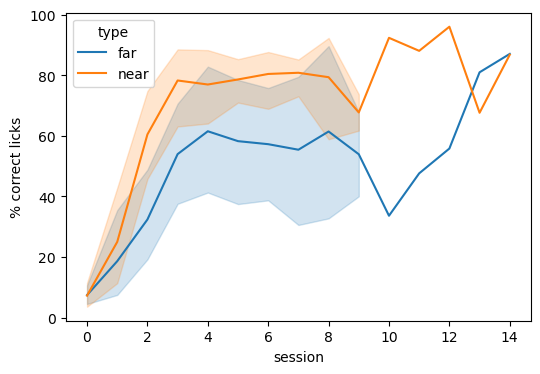

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.lineplot(data=data, x='session', y='score', hue='type', estimator='mean')
plt.ylabel('% correct licks')
plt.show()

In [10]:
# save
data.to_pickle("licking_data.pkl")

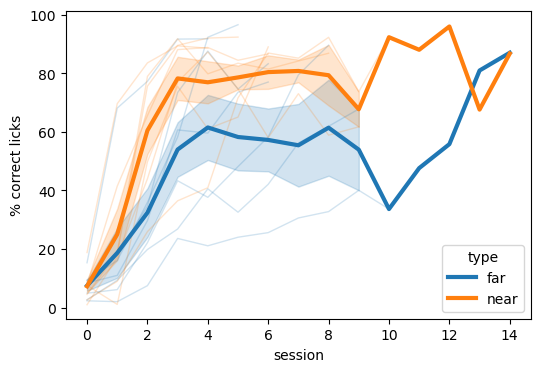

In [12]:
plt.figure(figsize=(6,4))

# individual mice (thin lines)
sns.lineplot(
    data=data, x='session', y='score',
    hue='type', units='animal',
    estimator=None, alpha=0.2, linewidth=1, legend=False)

# mean on top
sns.lineplot(
    data=data, x='session', y='score',
    hue='type', estimator='mean',
    errorbar='se', linewidth=3)

plt.ylabel('% correct licks')
plt.savefig(
    "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results/Learning_curve.pdf",
    format="pdf", dpi=300, bbox_inches="tight")

plt.show()

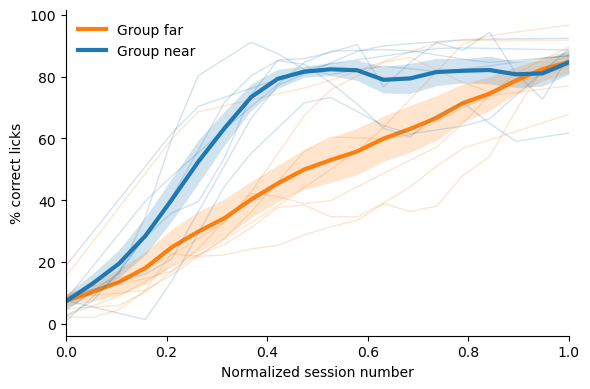

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import sem

# Common normalized x-axis
x_common = np.linspace(0, 1, 20)

fig, ax = plt.subplots(figsize=(6, 4))

colors = {'far': 'tab:orange', 'near': 'tab:blue'}

for group, df_group in data.groupby('type'):

    curves = []

    for animal, df in df_group.groupby('animal'):

        df = df.sort_values('session')

        x = df['session'].to_numpy(dtype=float)
        y = df['score'].to_numpy(dtype=float)

        # Normalize session number to [0, 1]
        x = (x - x.min()) / (x.max() - x.min())

        # Interpolate onto common x-axis
        f = interp1d(x, y, kind='linear')
        y_interp = f(x_common)

        curves.append(y_interp)

        # Individual animals
        ax.plot(x_common, y_interp,
                color=colors[group], alpha=0.2, lw=1)

    curves = np.asarray(curves)

    # Mean and SEM across animals
    mean = np.mean(curves, axis=0)
    error = sem(curves, axis=0)

    # Group mean
    ax.plot(x_common, mean,
            color=colors[group], lw=3,
            label=f'Group {group}')

    # SEM shading
    ax.fill_between(
        x_common,
        mean - error,
        mean + error,
        color=colors[group],
        alpha=0.2,
        linewidth=0
    )

ax.set(
    xlabel='Normalized session number',
    ylabel='% correct licks',
    xlim=(0, 1)
)

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()

plt.savefig(
    "/home/mohammad/nas4/mohammad.yaghoubi/VR-2p/Results/Learning_curve.pdf",
    format="pdf", dpi=300, bbox_inches="tight"
)

plt.show()